# YOLO Classification 학습

- YOLO 모델 학습
- 원본 스크립트: `train_yolo_cls.py`

YOLO Classification 학습 스크립트

AWS 아이콘 분류 모델을 YOLO로 학습합니다.
conda archlens 환경에서 실행합니다.

사용법:
    python scripts/train_yolo_cls.py --mode fine --epochs 100 --imgsz 256
    python scripts/train_yolo_cls.py --mode coarse --epochs 50 --imgsz 128

In [1]:
from __future__ import annotations
import argparse, sys
from pathlib import Path
from typing import Optional

# conda activate archlens
# pip install ultralytics
from ultralytics import YOLO

def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="YOLO-CLS 학습 설정")
    parser.add_argument("--mode", choices=["fine", "coarse"], default="fine")
    parser.add_argument("--data-dir", type=Path, default=Path("./dataset/icons"))
    parser.add_argument("--model", default="weights/yolov8n-cls.pt")
    parser.add_argument("--epochs", type=int, default=50)
    parser.add_argument("--imgsz", type=int, default=256)
    parser.add_argument("--batch", type=int, default=32)
    parser.add_argument("--name", default="yolo-cls")
    return parser.parse_args(args=[])


def prepare_paths(mode: str, data_dir: Path) -> Path:
    if not data_dir.exists():
        raise FileNotFoundError(f"데이터셋 디렉터리가 없습니다: {data_dir}")

    yolo_data_dir = data_dir / f"yolo_cls_{mode}"
    if not yolo_data_dir.exists():
        raise FileNotFoundError(
            f"YOLO 데이터셋 디렉터리가 없습니다: {yolo_data_dir}\n"
            f"먼저 다음 명령을 실행하세요:\n"
            f"  ./aws_icon_yolo_cls_prepare_and_train.sh {mode} {data_dir}"
        )

    for split in ["train", "val"]:
        split_dir = yolo_data_dir / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Split 디렉터리가 없습니다: {split_dir}")

    return yolo_data_dir


# ---- Config ----
args = parse_args()
MODE = args.mode
DATA_DIR = args.data_dir
YOLO_DATA_DIR = prepare_paths(MODE, DATA_DIR)

print(f"[INFO] MODE       = {MODE}")
print(f"[INFO] DATA_DIR   = {DATA_DIR}")
print(f"[INFO] YOLO DATA  = {YOLO_DATA_DIR}")
print(f"[INFO] MODEL      = {args.model}")
print(f"[INFO] EPOCHS     = {args.epochs}, IMGSZ = {args.imgsz}, BATCH = {args.batch}")
print(f"[INFO] RUN NAME   = {args.name}")

[INFO] MODE       = fine
[INFO] DATA_DIR   = dataset/icons
[INFO] YOLO DATA  = dataset/icons/yolo_cls_fine
[INFO] MODEL      = weights/yolov8n-cls.pt
[INFO] EPOCHS     = 50, IMGSZ = 256, BATCH = 32
[INFO] RUN NAME   = yolo-cls


In [2]:
def run_training():
    """Ultralytics YOLO 분류 학습을 실행한다."""

    model = YOLO(args.model)
    results = model.train(
        data=str(YOLO_DATA_DIR),
        epochs=args.epochs,
        imgsz=args.imgsz,
        batch=args.batch,
        name=args.name,
        project="runs/classify",
        task="classify",
        mode="train",
    )
    return results

results = run_training()
results

New https://pypi.org/project/ultralytics/8.3.235 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.233 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32108MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/icons/yolo_cls_fine, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=weights/yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo-cls16

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x749d483b5210>
curves: []
curves_results: []
fitness: 0.4947916641831398
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.2395833283662796, 'metrics/accuracy_top5': 0.75, 'fitness': 0.4947916641831398}
save_dir: PosixPath('/home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16')
speed: {'preprocess': 0.020819177204126998, 'inference': 0.06129901044005237, 'loss': 5.416670016226514e-05, 'postprocess': 8.223954258331408e-05}
task: 'classify'
top1: 0.2395833283662796
top5: 0.75

In [7]:
# ---- 학습 결과 요약/산출물 확인 ----
from pathlib import Path
import json
from IPython.display import display, Image
import pandas as pd
import os


def find_run_dir(base: Path, preferred: str) -> Path:
    """가장 큰 번호 yolo-cls*를 우선 선택하고, 없을 때만 fallback."""

    import re

    numbered: list[tuple[int, Path]] = []
    for p in base.iterdir():
        if not p.is_dir():
            continue
        m = re.match(r"^yolo-cls(\d+)$", p.name)
        if m:
            numbered.append((int(m.group(1)), p))
    if numbered:
        return max(numbered, key=lambda t: t[0])[1]

    # 번호 패턴이 없으면 preferred가 있으면 그걸, 없으면 mtime 최신
    pref = base / preferred
    if pref.is_dir():
        return pref

    candidates = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    return candidates[0] if candidates else pref


base_dir = Path("runs/classify").resolve()
# args가 없는 경우에도 동작하도록 안전한 기본값 설정
default_name = "yolo-cls"
args_name = getattr(args, "name", default_name) if "args" in globals() else default_name
run_dir = find_run_dir(base_dir, args_name).resolve()

metrics_csv = (run_dir / "results.csv").resolve()
conf_mat_png = (run_dir / "confusion_matrix.png").resolve()
roc_png = (run_dir / "ROC.png").resolve()
pr_png = (run_dir / "PR_curve.png").resolve()
best_pt = (run_dir / "weights" / "best.pt").resolve()
last_pt = (run_dir / "weights" / "last.pt").resolve()

print(f"[INFO] run_dir: {run_dir}")

if metrics_csv.exists():
    df_metrics = pd.read_csv(metrics_csv)
    print("[INFO] metrics tail:")
    display(df_metrics.tail())
else:
    print(f"[WARN] metrics csv not found: {metrics_csv}")

for path, label in [
    (best_pt, "best.pt"),
    (last_pt, "last.pt"),
    (conf_mat_png, "confusion_matrix.png"),
    (roc_png, "ROC.png"),
    (pr_png, "PR_curve.png"),
]:
    print(f"{label}: {'OK' if path.exists() else 'MISSING'} -> {path}")

[INFO] run_dir: /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16
[INFO] metrics tail:


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
45,46,11.5569,1.98707,0.25000,0.75000,2.40234,0.000016,0.000016,0.000016
46,47,11.7682,2.01752,0.21875,0.75000,2.47070,0.000013,0.000013,0.000013
47,48,11.9660,1.98537,0.21875,0.73958,2.46875,0.000010,0.000010,0.000010
48,49,12.1729,1.99533,0.20833,0.75000,2.35840,0.000007,0.000007,0.000007
49,50,12.3842,1.99086,0.20833,0.75000,2.37500,0.000004,0.000004,0.000004


best.pt: OK -> /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/weights/best.pt
last.pt: OK -> /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/weights/last.pt
confusion_matrix.png: OK -> /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/confusion_matrix.png
ROC.png: MISSING -> /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/ROC.png
PR_curve.png: MISSING -> /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16/PR_curve.png


[INFO] Using run_dir: /home/wsm/workspace/hit-archlens-project/runs/classify/yolo-cls16

[GROUP] confusion (2 files)


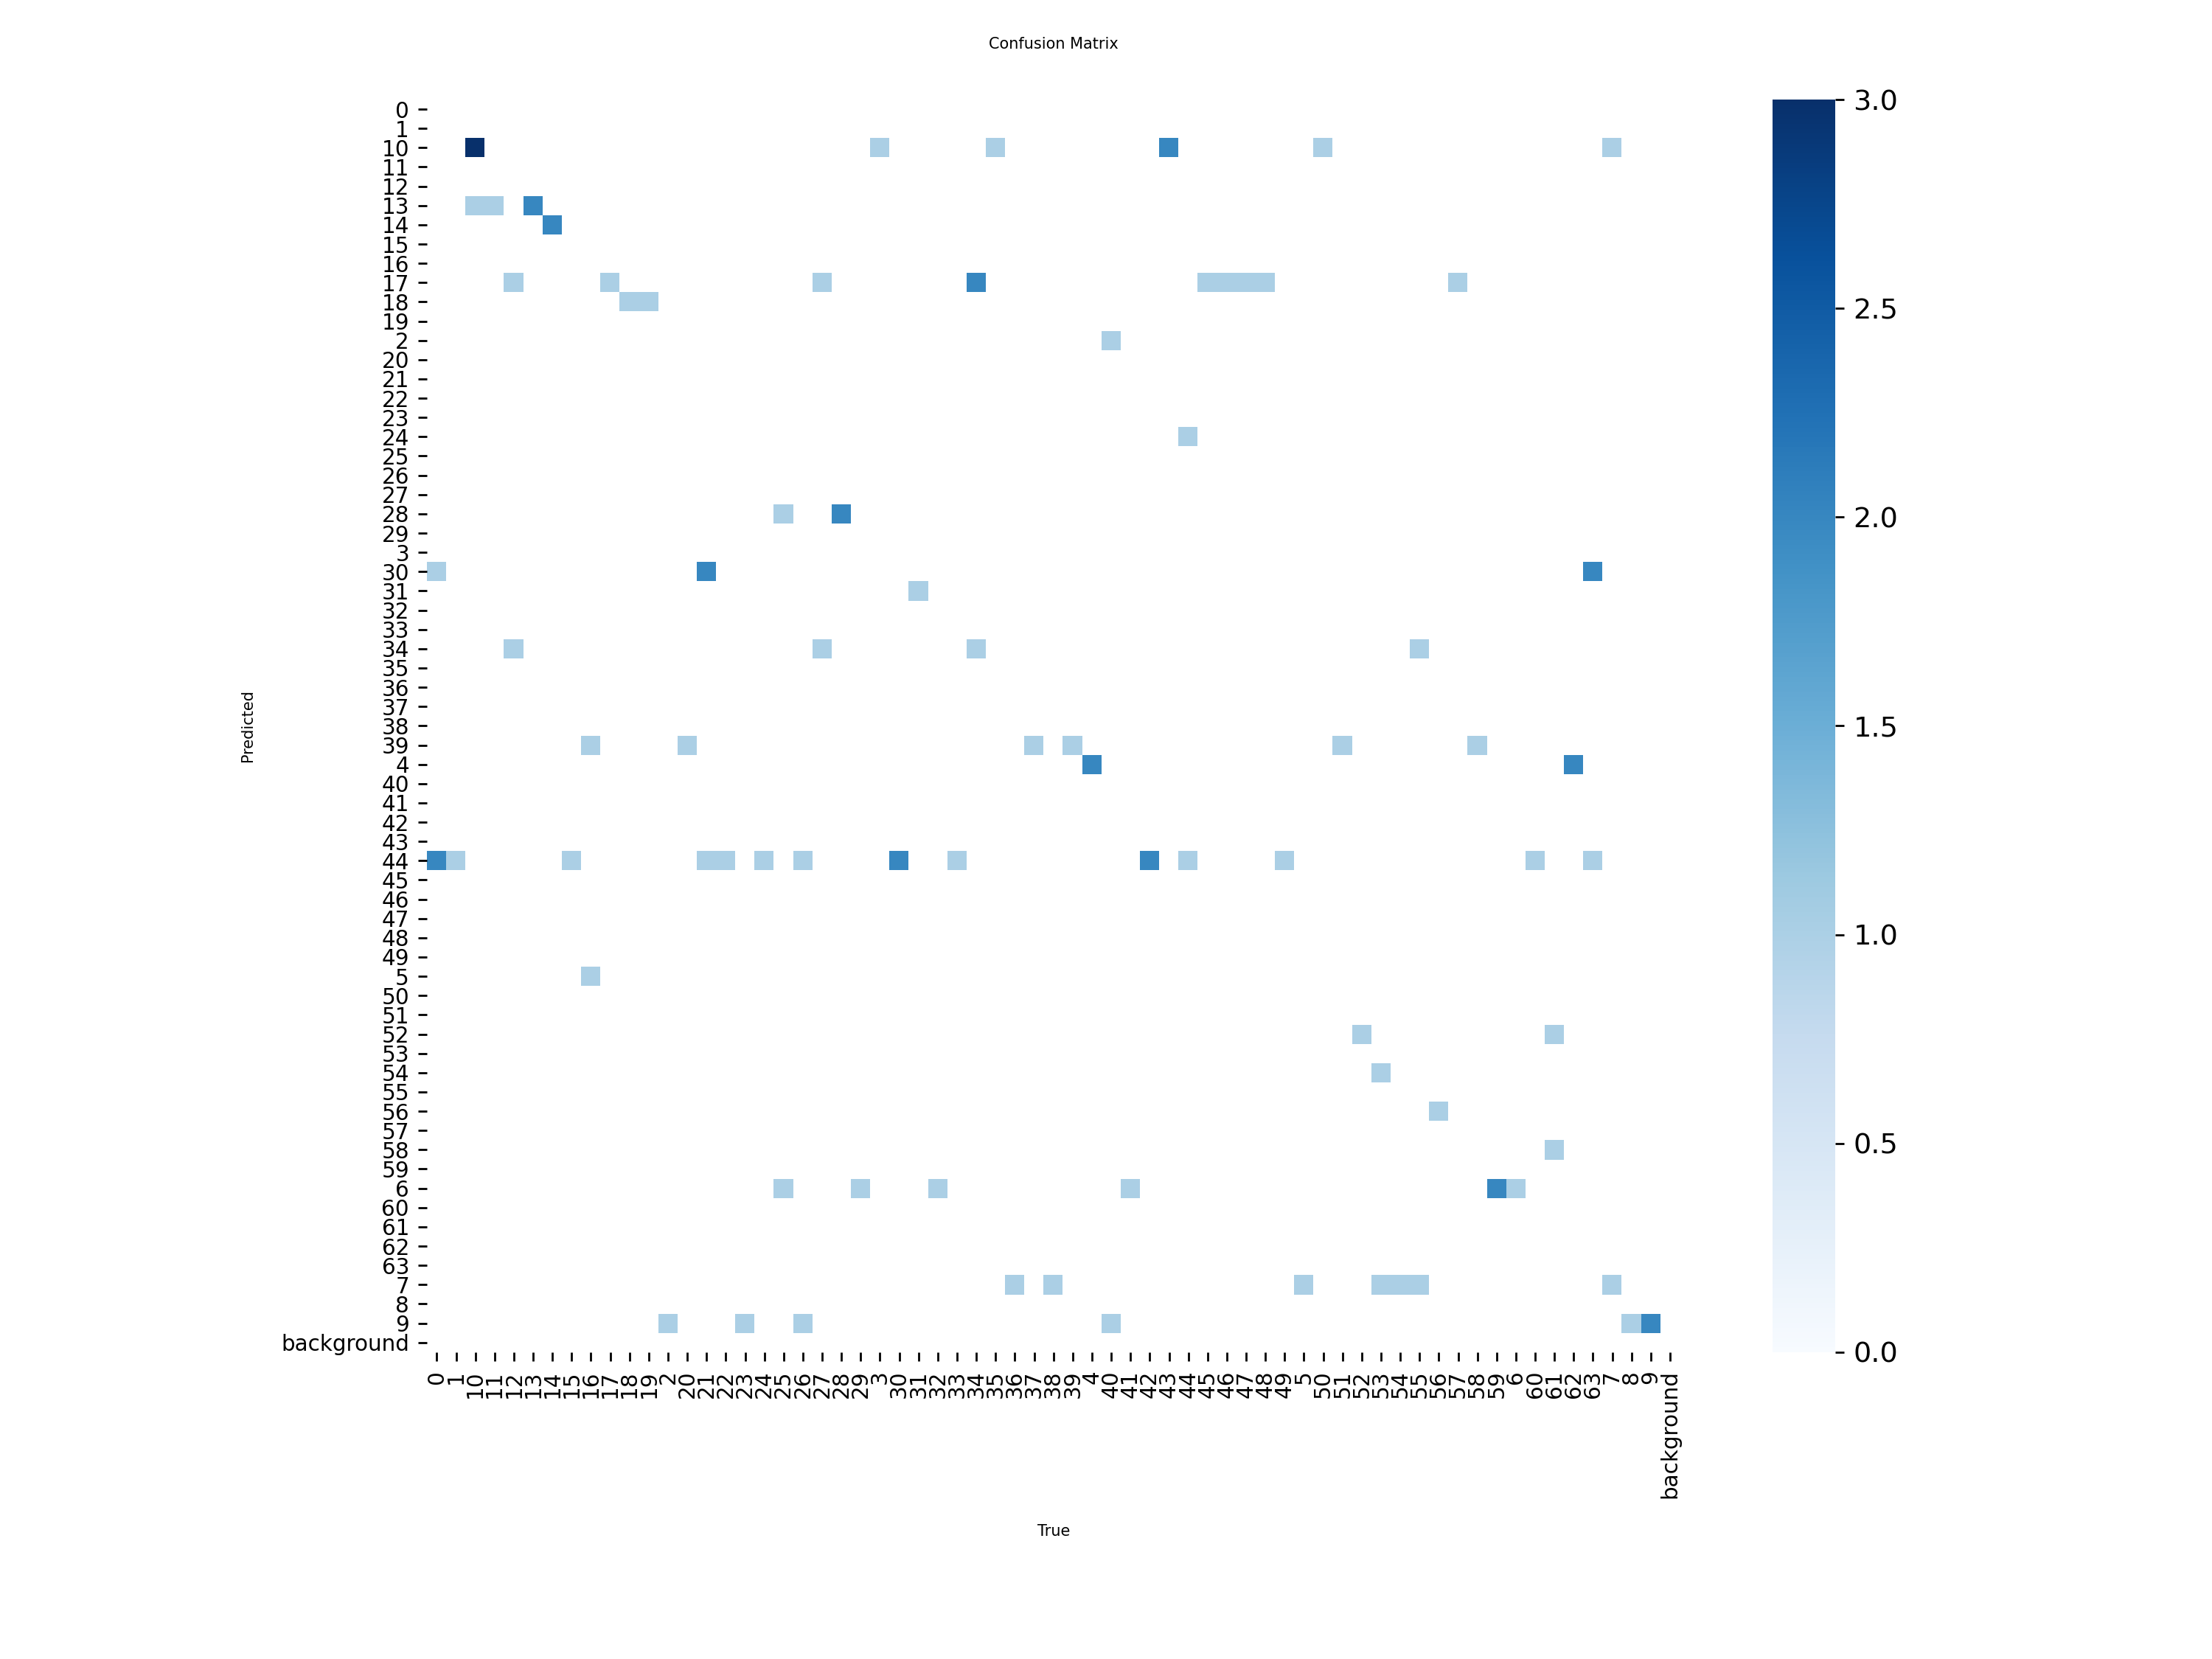

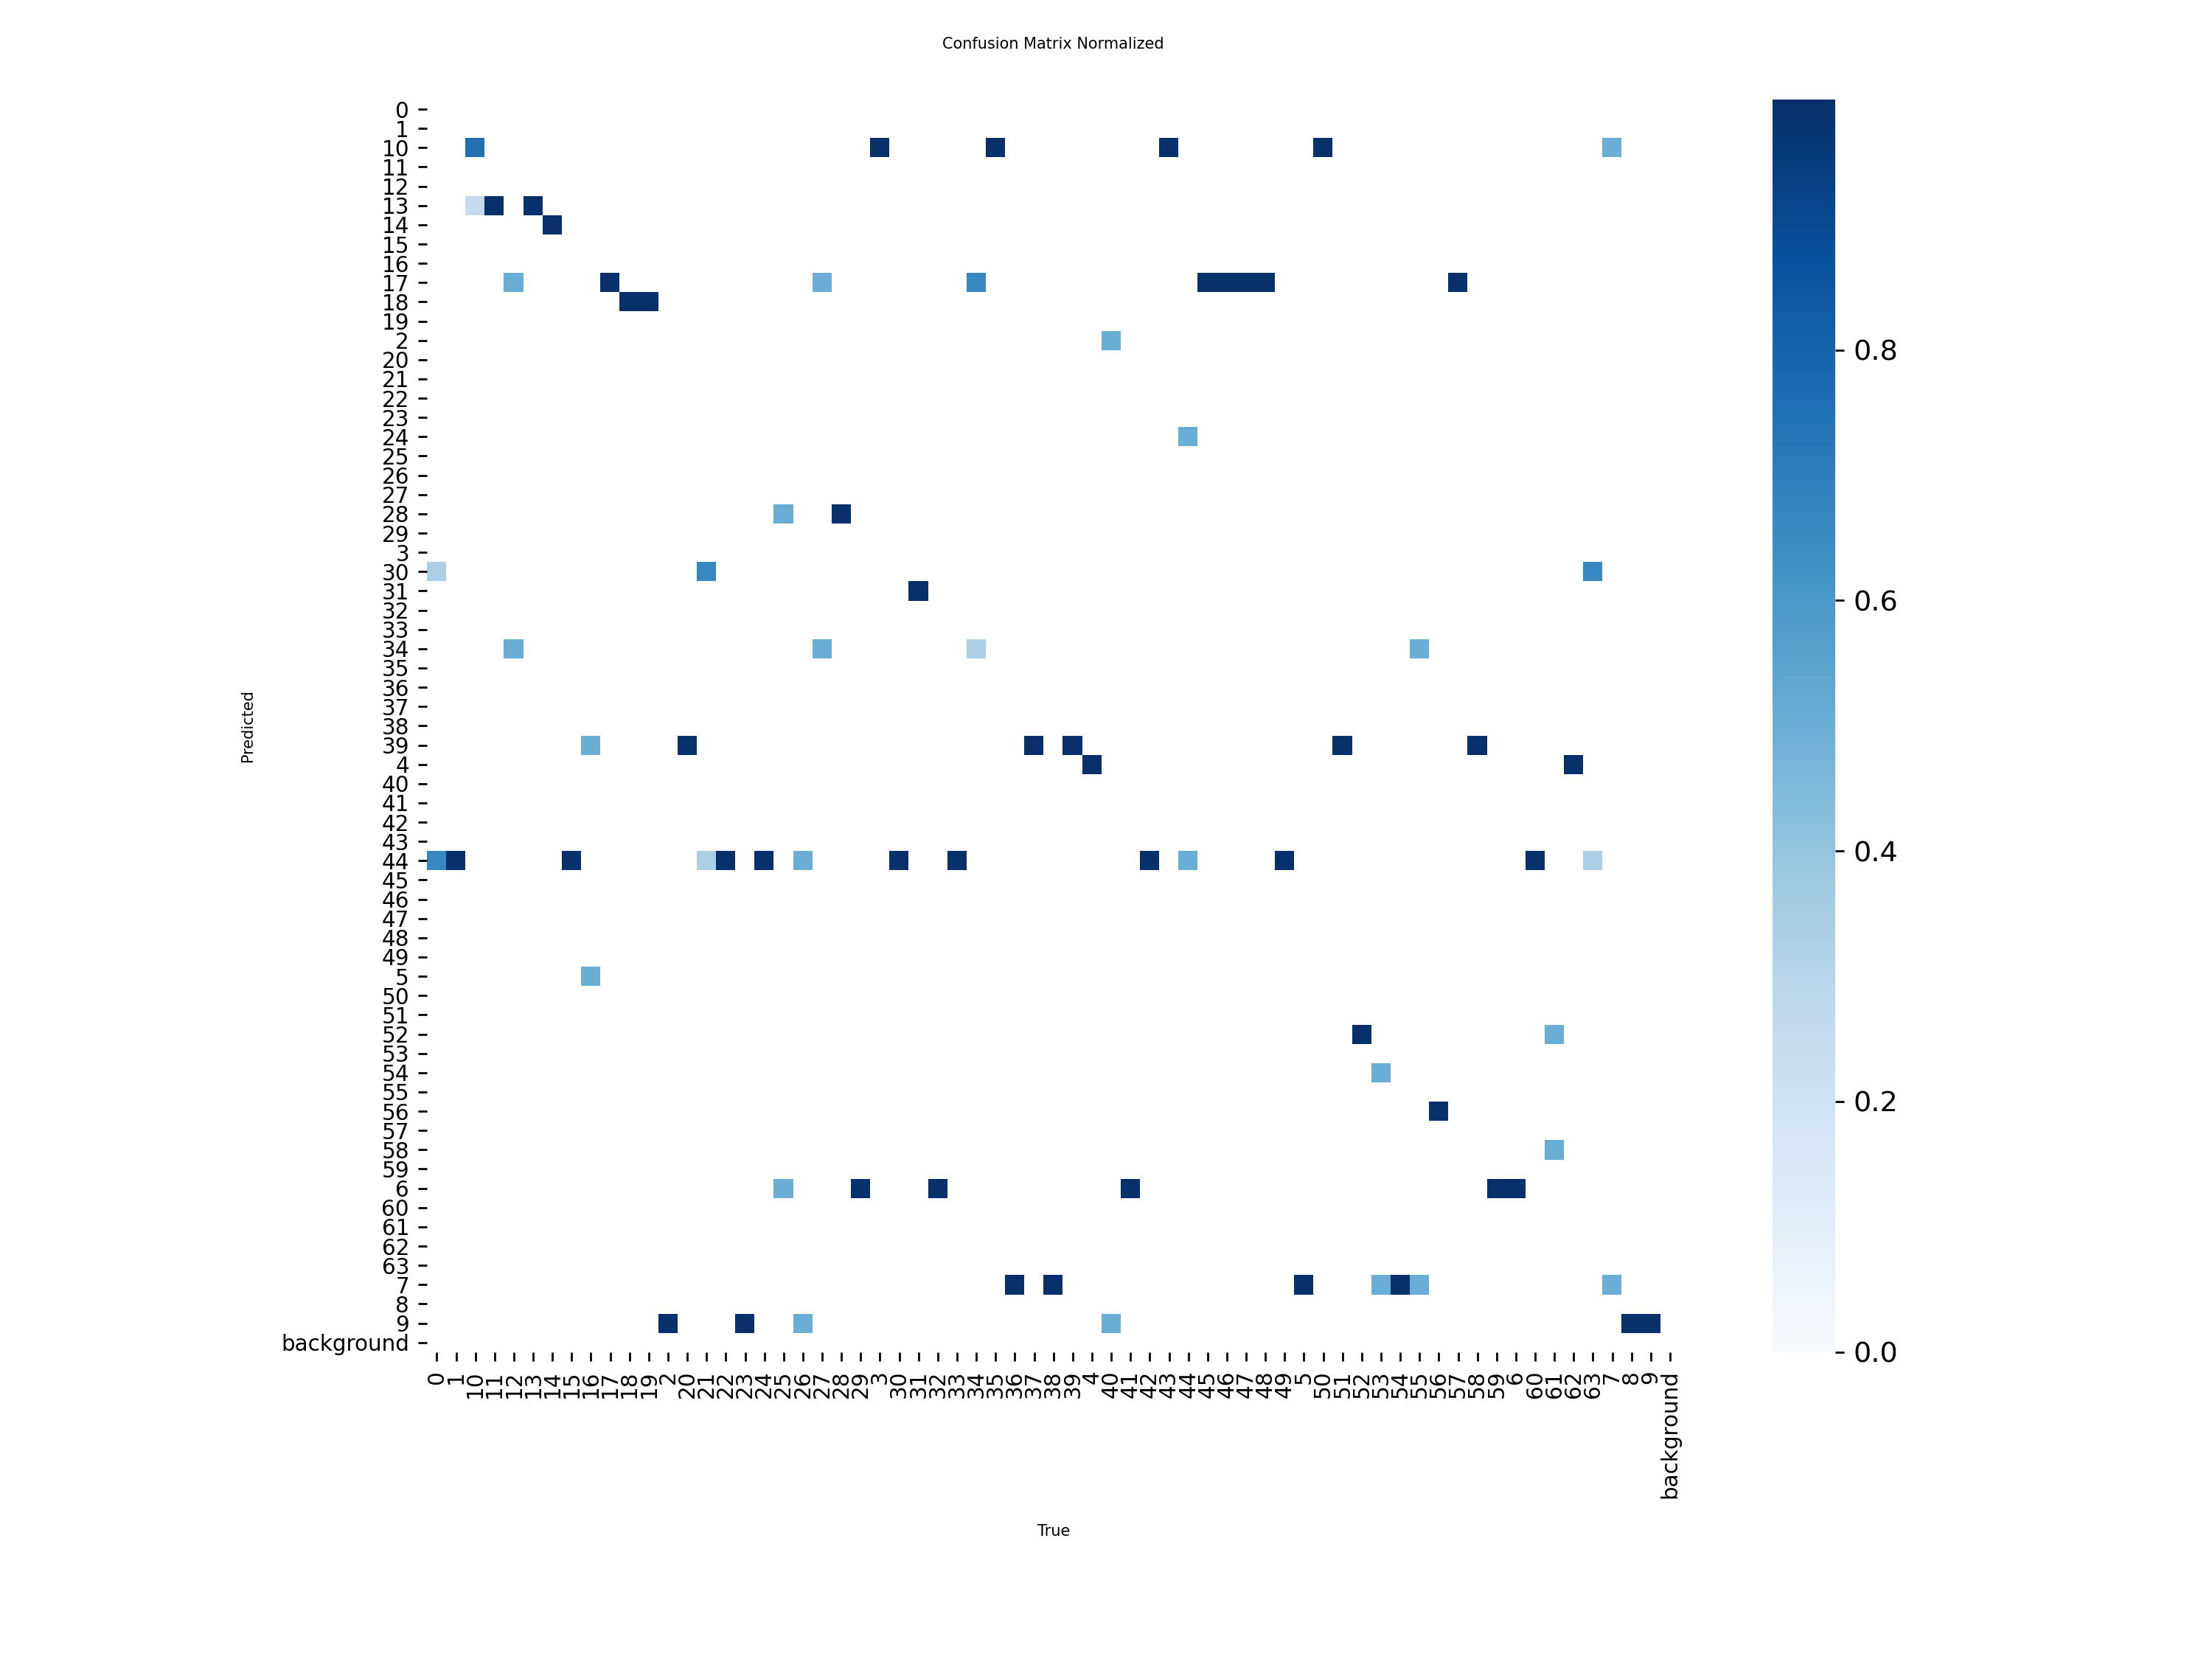


[GROUP] results (1 files)


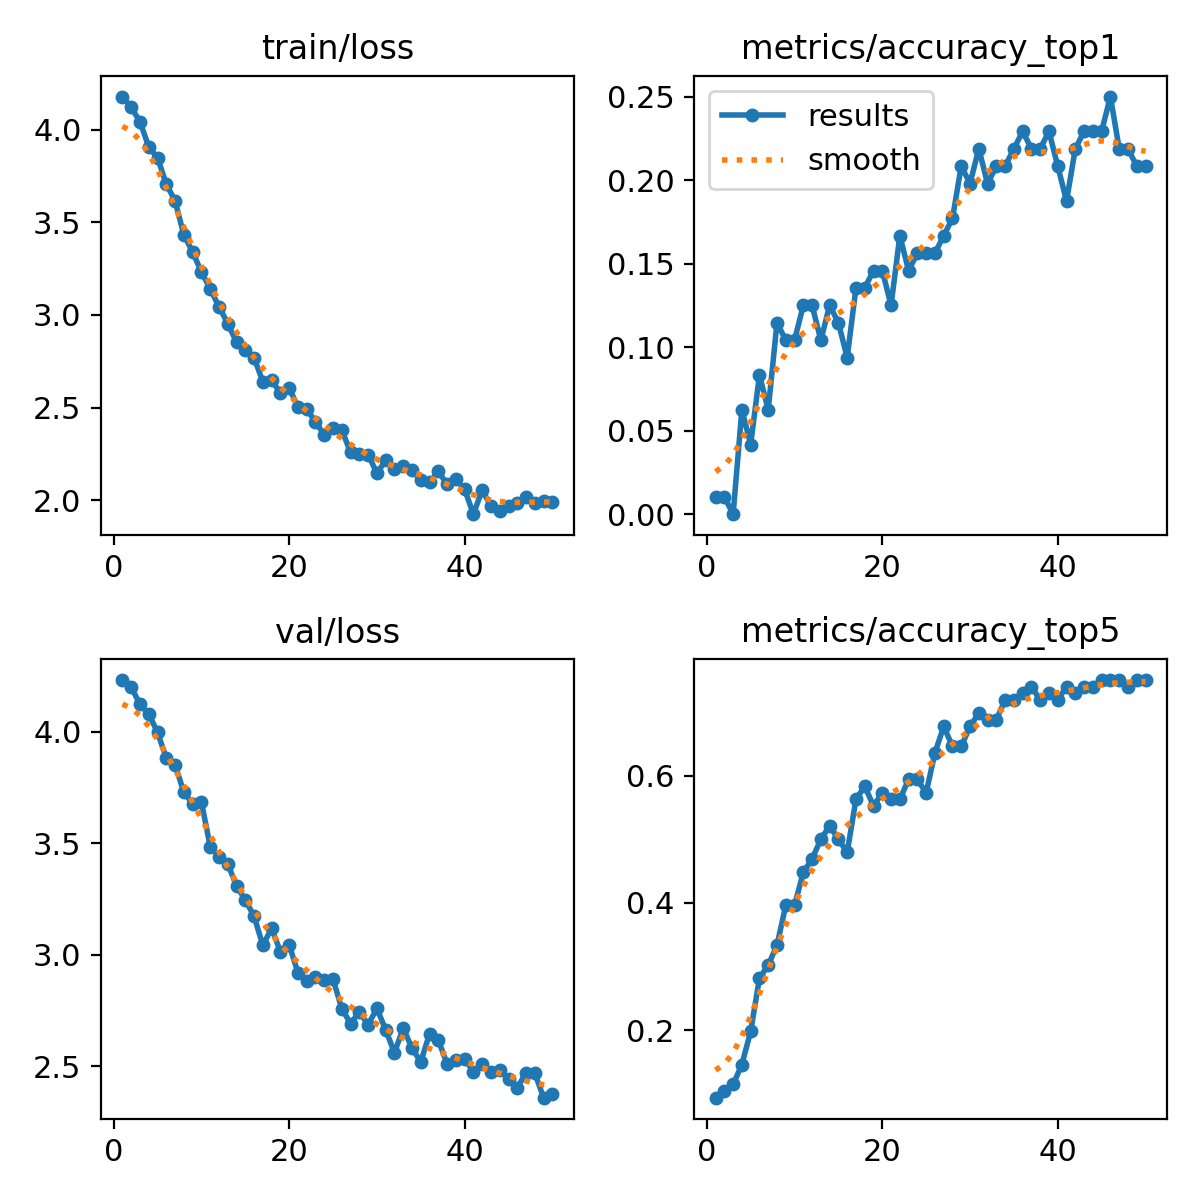


[GROUP] train (6 files)


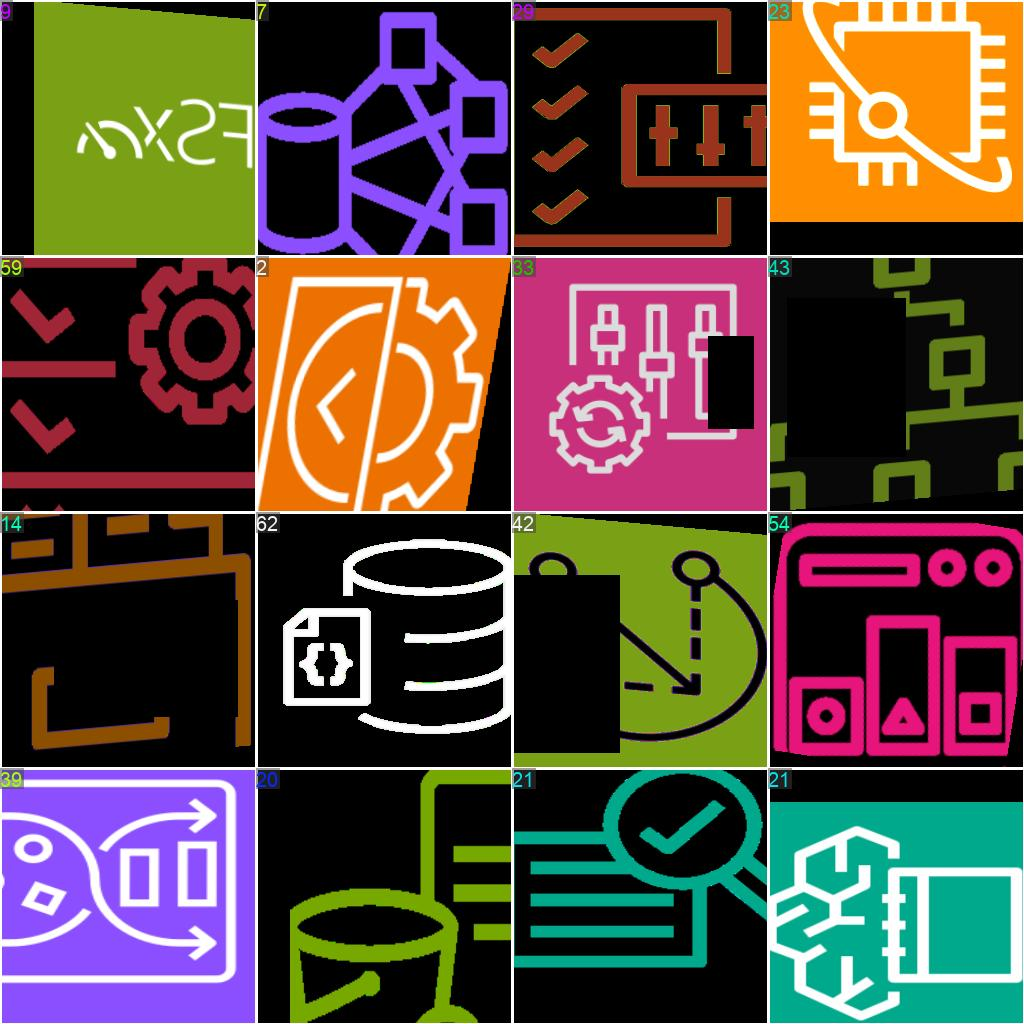

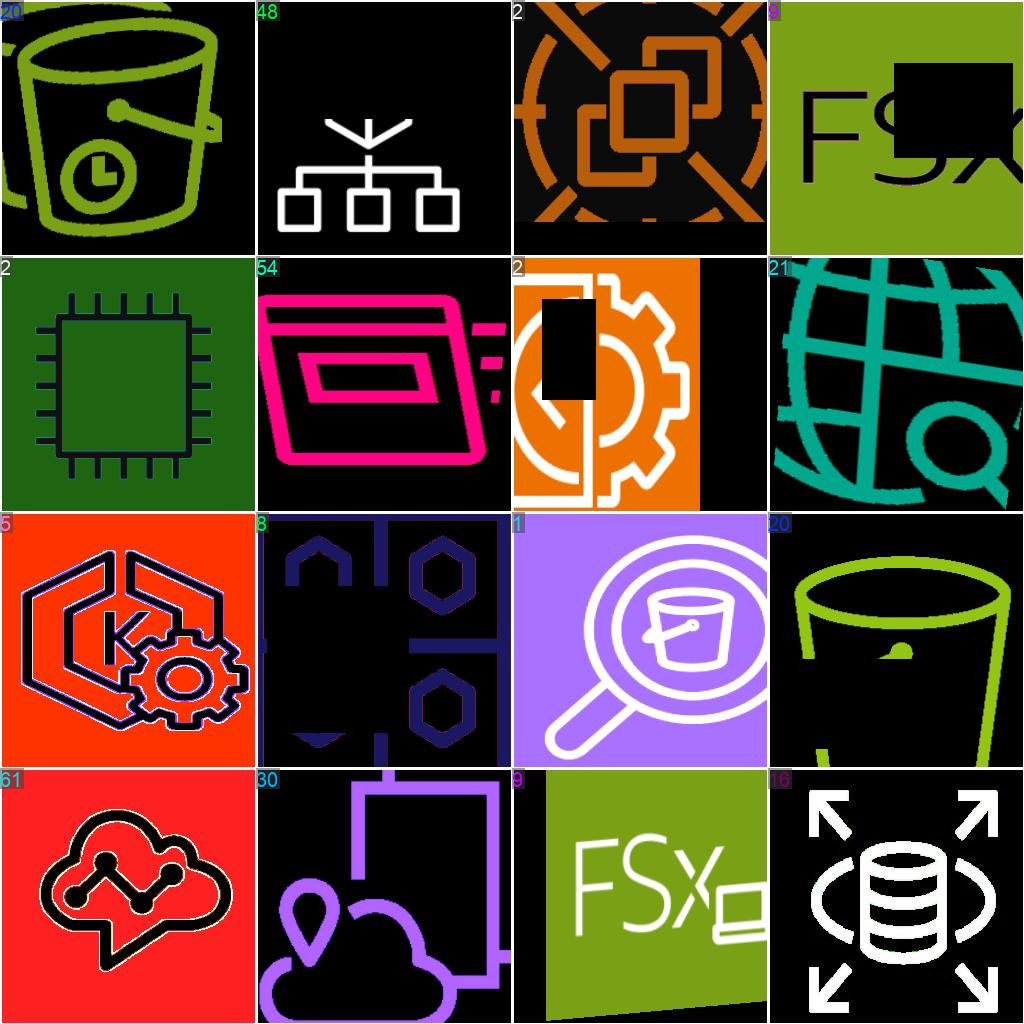

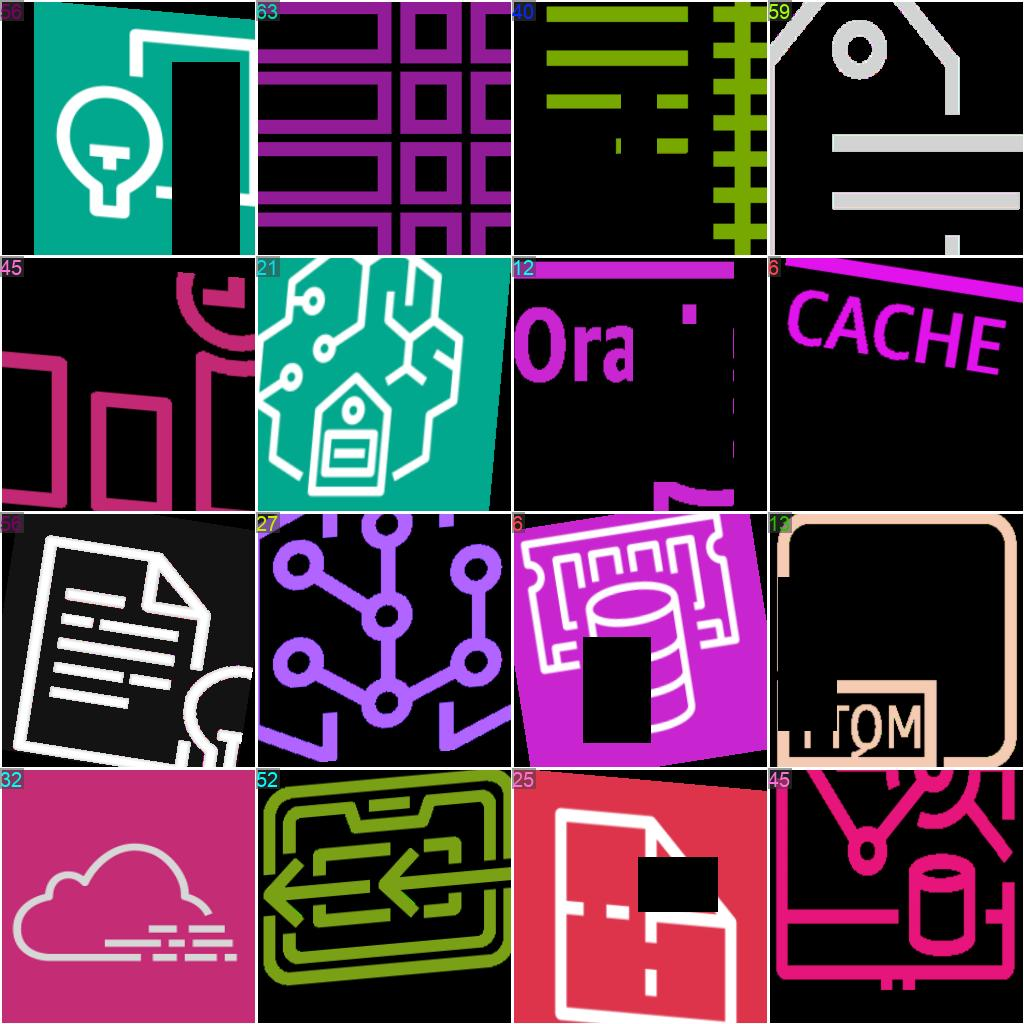

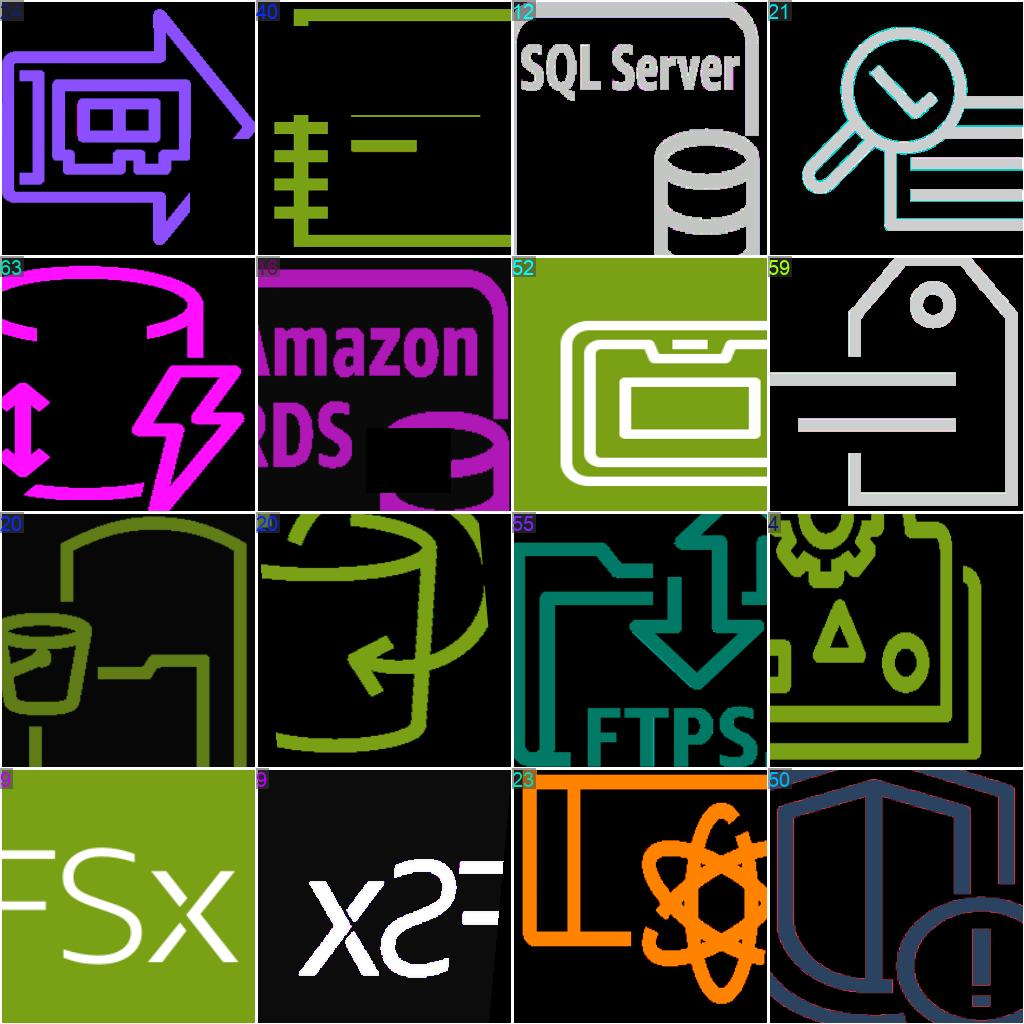

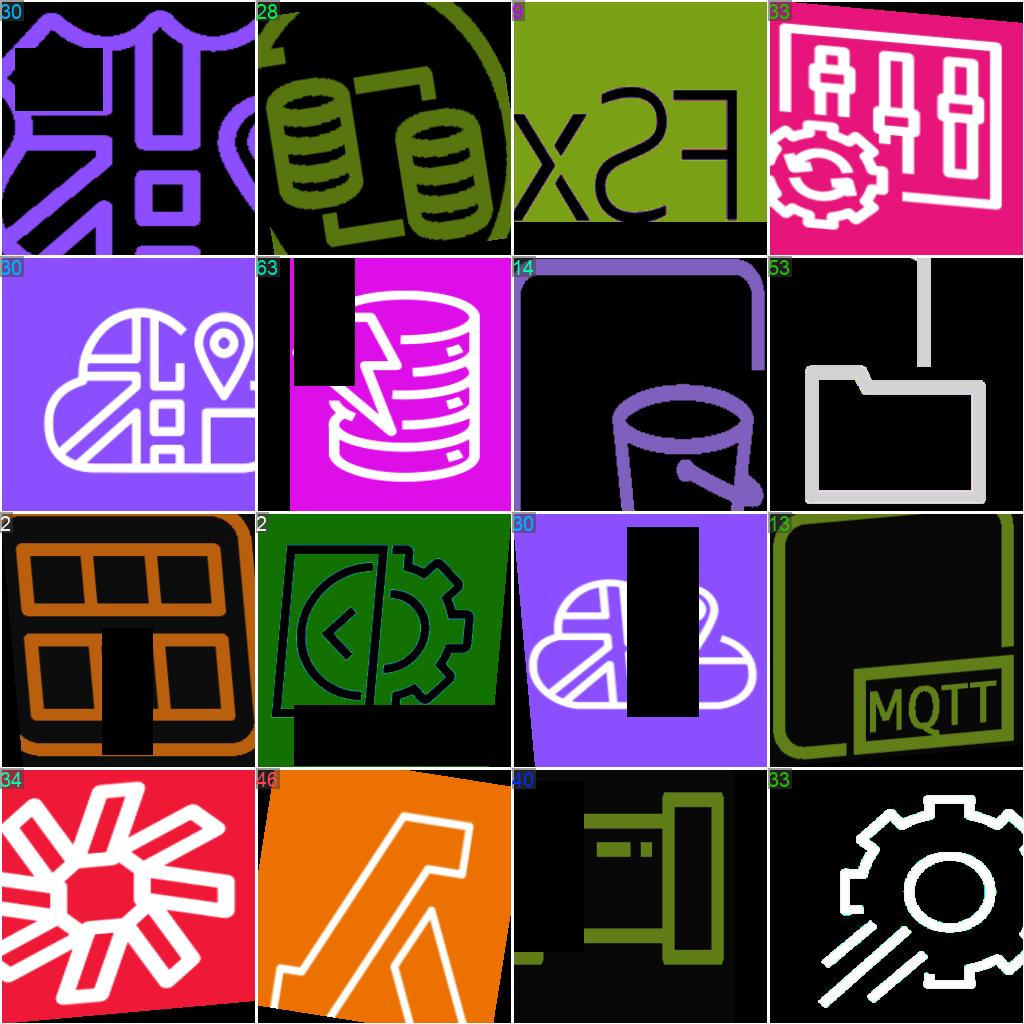

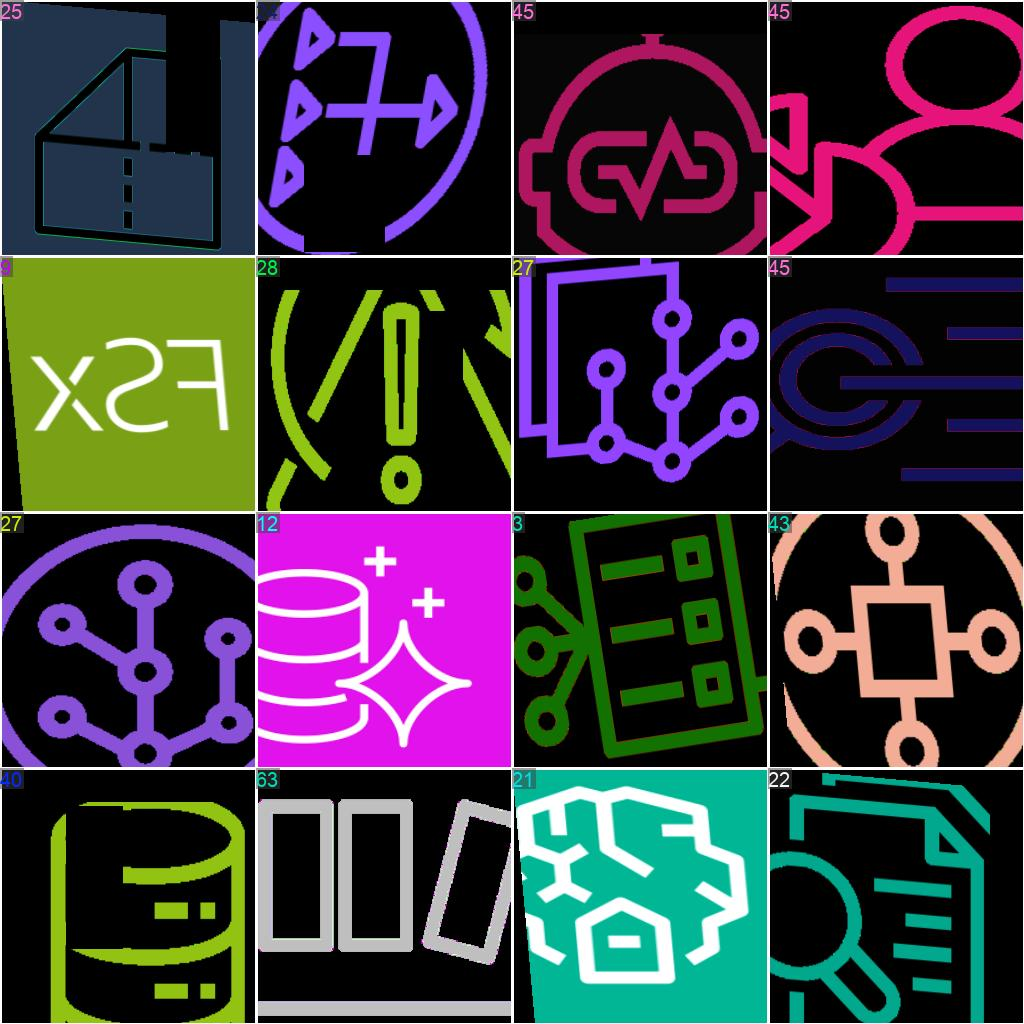


[GROUP] val (4 files)


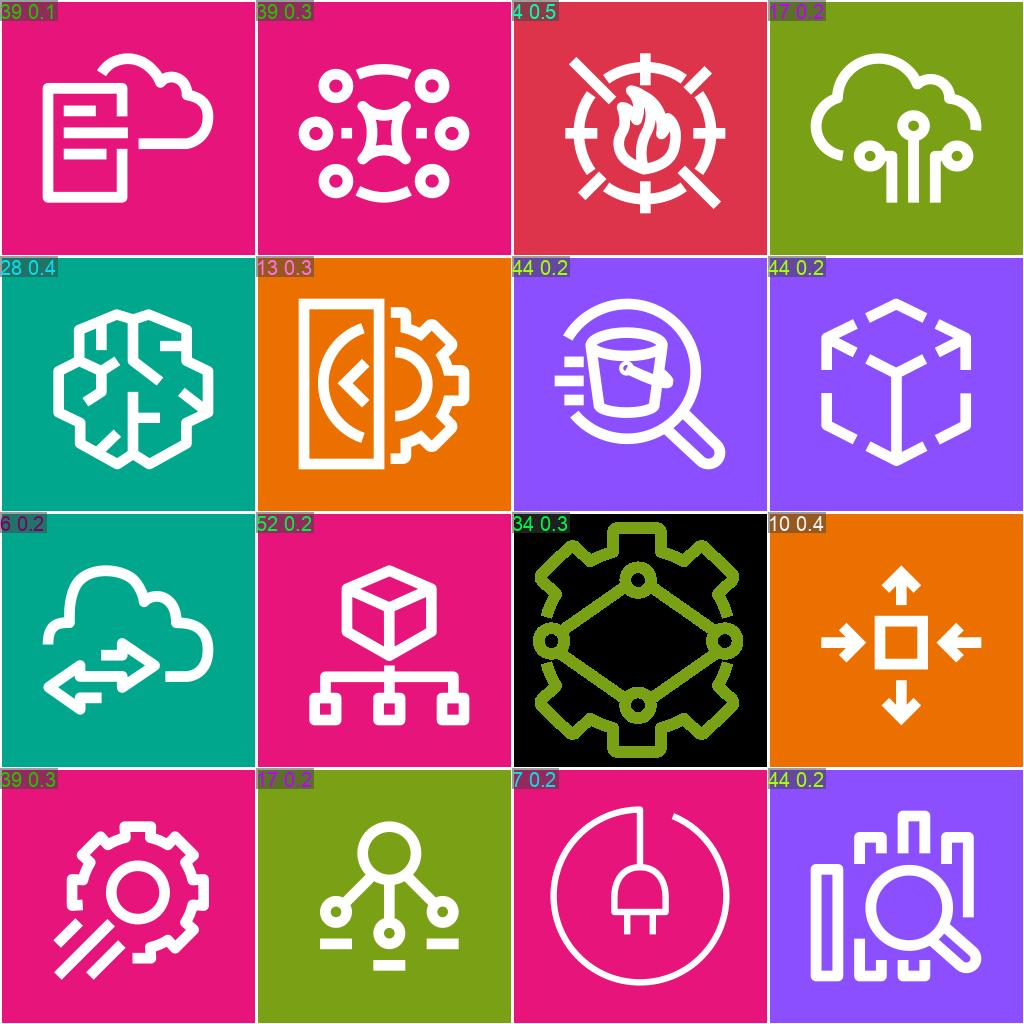

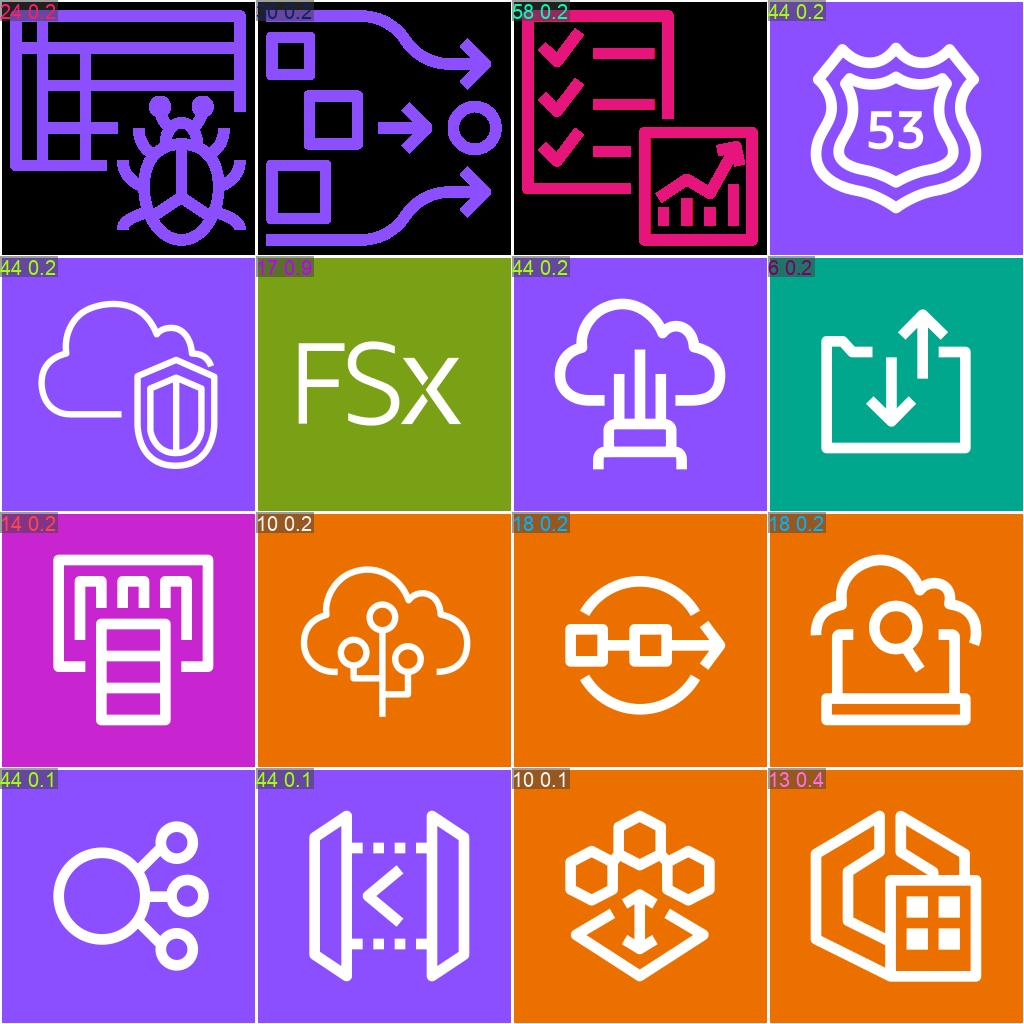

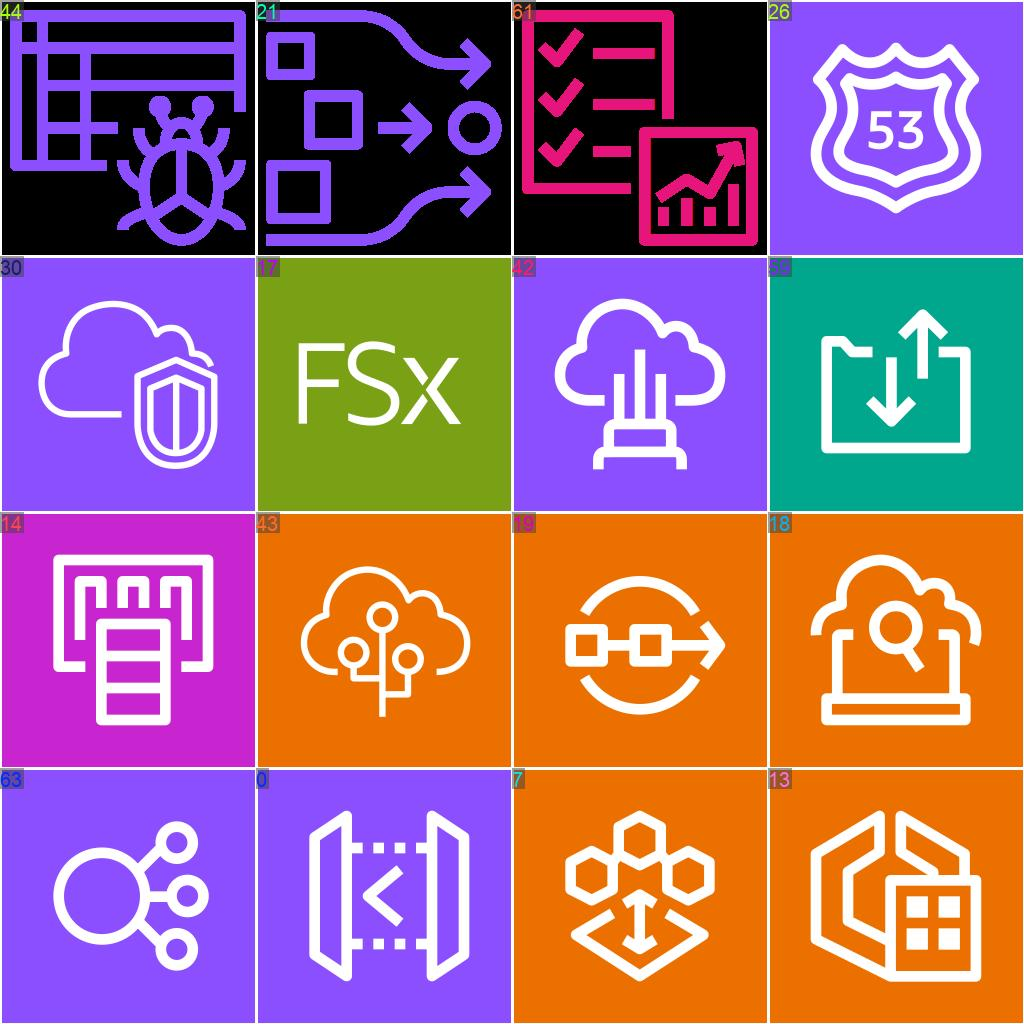

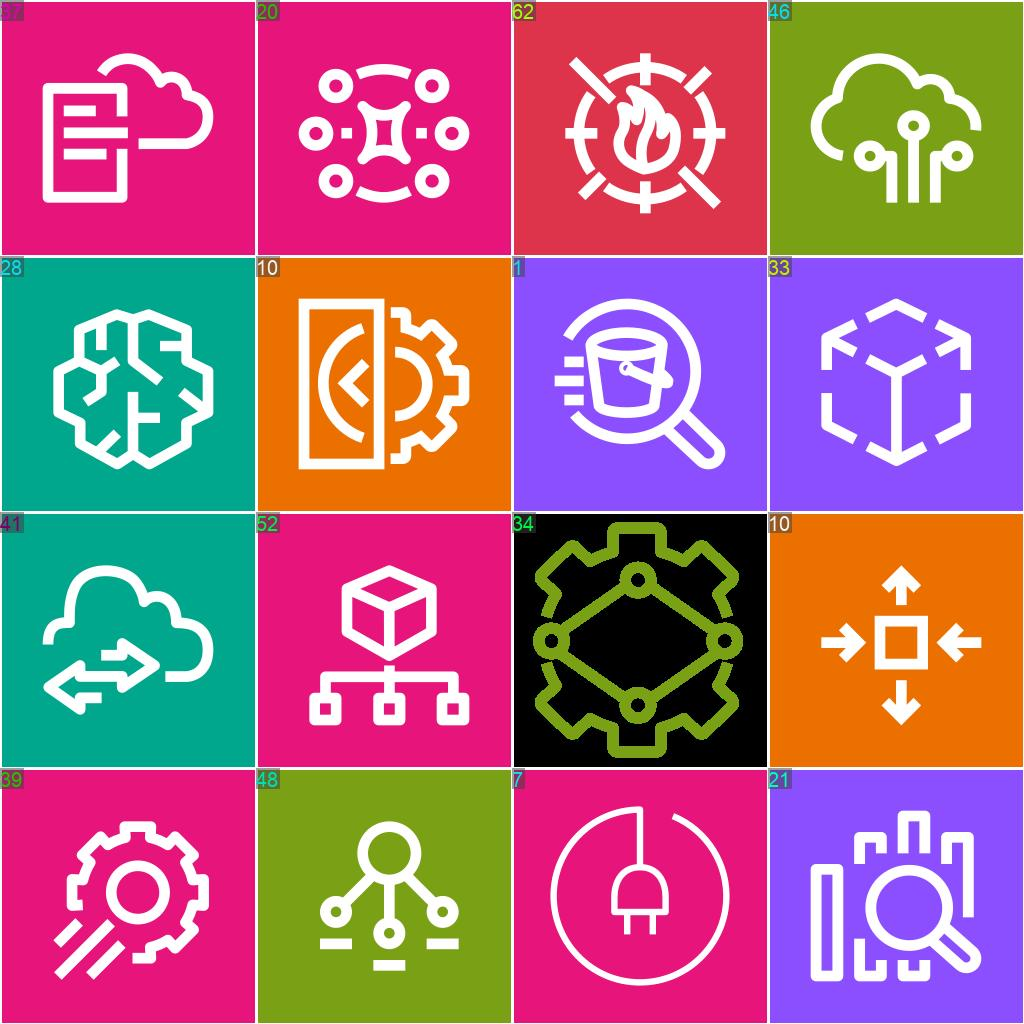

In [ ]:
# 그래프 이미지 출력 (존재하는 것만 표시)
# run_dir이 정의되지 않은 채 셀만 실행하는 경우를 대비
if "run_dir" not in globals():
    base_dir = Path("runs/classify").resolve()
    default_name = "yolo-cls"
    run_dir = find_run_dir(base_dir, default_name).resolve()

print(f"[INFO] Using run_dir: {run_dir}")

# 페이지네이션 설정 (start를 바꿔가며 화살표 대신 활용)
start = 0      # 보고 싶은 시작 인덱스(0-based)
page_size = 12 # 한 번에 볼 이미지 수

# run_dir 내 이미지 자동 탐색 (png/jpg) → 최근 수정 순으로 정렬
img_files = sorted(
    [p for p in run_dir.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
img_files = img_files[start : start + page_size]

from collections import defaultdict
from IPython.display import HTML

def prefix_key(path: Path) -> str:
    name = path.name
    for pref in ["confusion_", "confusion", "results", "train_", "val_", "test_", "train", "val", "test"]:
        if name.startswith(pref):
            return pref.rstrip("_")
    return "others"

groups: dict[str, list[Path]] = defaultdict(list)
for p in img_files:
    groups[prefix_key(p)].append(p)

if not img_files:
    print("[WARN] 표시할 그래프/이미지가 없습니다. run_dir 내부의 .png/.jpg를 확인하세요.")
else:
    print(f"[INFO] showing {len(img_files)} files (start={start}, page_size={page_size})")
    thumb_w = 180
    for gname in sorted(groups.keys()):
        print(f"\n[GROUP] {gname} ({len(groups[gname])} files)")
        for p in groups[gname]:
            display(HTML(f"<b>{p.name}</b>"))
            display(Image(filename=str(p), width=thumb_w))